# Demo 2: Controlled Pendulum
## Demo 2.6: Hybrid - Unified within SysSimX Framework

In [1]:
from time import time
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))

In [2]:
from SysSimX.utilities.update_fmus import get_fmu_paths
from SysSimX.components.fmu_comp import FMUComponent

demo_dir_path = Path(repo_root / 'demos' / 'ControlledPendulum')
package_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum/'
fmu_output_dir = Path.cwd() / 'MyModels/FMUs/'
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=False)

fmu_paths

All FMUs for package 'ControlledPendulum' already exist. Skipping generation.


{'AngleEncoder': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/AngleEncoder.fmu'),
 'Demo_Driven': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Demo_Driven.fmu'),
 'Drive': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive.fmu'),
 'ImpactWall': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/ImpactWall.fmu'),
 'PID_Continuous': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/PID_Continuous.fmu'),
 'Pendulum': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Pendulum.fmu'),
 'PendulumWithWallContinuous': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/PendulumWithWallContinuous.fmu'),
 'Reference': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Reference.fmu')}

In [3]:
ref          = FMUComponent(name='ref', fmu_path=fmu_paths['Reference'], group='Input')
sensor_ref   = FMUComponent(name='sensor_ref', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
sensor_state = FMUComponent(name='sensor_state', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
pid          = FMUComponent(name='pid', fmu_path=fmu_paths['PID_Continuous'], group='Control')
drive        = FMUComponent(name='drive', fmu_path=fmu_paths['Drive'], group='Actuator')
eqb_pendulum = FMUComponent(name='EQB_Pendulum', fmu_path=fmu_paths['Pendulum'], group='Plant')

In [4]:
# Reference trajectory
ref_freq = 0.2 # Hz
q_mean_deg = 0
q_ampl_deg = 5
ref_params ={}
ref_params['amplitude'] = np.deg2rad(q_ampl_deg)
ref_params['mean'] = np.deg2rad(q_mean_deg)
ref_params['frequency'] = ref_freq
ref.set_parameters(**ref_params)

# Sensor Configuration
nbits = 12
sensor_params = {}
sensor_params['q_max'] = np.deg2rad(q_mean_deg + q_ampl_deg)
sensor_params['q_min'] = np.deg2rad(q_mean_deg + q_ampl_deg)
sensor_ref.parameters['nBits'].start = nbits
sensor_ref.set_parameters(**sensor_params)
sensor_state.set_parameters(**sensor_params)

# PID Controller Configuration
pid_params = {}
pid_params['k'] = 10
pid_params['Ti'] = 0.5
pid_params['Td'] = 0.25
pid.set_parameters(**pid_params)

In [5]:
from MyModels.FEM.fem_pendulum import FEMPendulum
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum
from MyModels.pendulum_multi_comp import PendulumMultiComp


# Simulation paramters
t0, h, tf = 0, 0.01, 5

# Initial Conditions
q0_deg  = 0
q0      = np.deg2rad(q0_deg)
omega0  = 0
q_wall_deg = 0

# Define FEM model
fem_pendulum  = FEMPendulum("FEM_Pendulum", group="Plant")

fem_pendulum._with_contact = False
fem_pendulum.geom_params.q_wall_deg = q_wall_deg
fem_pendulum.sim_params.t_start = t0
fem_pendulum.sim_params.tau     = h
fem_pendulum.sim_params.t_end   = tf
fem_pendulum.init_params.angular_position_deg = q0_deg
fem_pendulum.init_params.angular_velocity     = omega0

os_pendulum   = OpenSimPendulum("OpenSim_Pendulum", group="Plant")

pendulum = PendulumMultiComp(fem_comp=fem_pendulum,
                             opensim_comp=os_pendulum,
                             fmu_comp=eqb_pendulum)


In [6]:
for component in [ref, sensor_ref, sensor_state, pid, drive, pendulum]:
    component.initialize(t0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [7]:
t = t0

while t <= tf:
        # 1) Get reference signal
        ref.do_step(t, h)
        q_ref = ref.get_outputs()['q_ref']

        # 2) Get plant outputs at current time
        plant_out = pendulum.get_outputs()
        q_state, omega_state = plant_out['q'], plant_out['omega']   

        # 4) Feed reference and state to sensor models
        sensor_ref.set_inputs({'q':q_ref}, t); 
        sensor_state.set_inputs({'q': q_state}, t)
                
        sensor_ref.do_step(t, h)
        sensor_state.do_step(t, h)

        U_q_ref = sensor_ref.get_outputs()['U_q']
        U_q_state = sensor_state.get_outputs()['U_q']

        # 5) Feed sensor outputs to PID controller
        pid.set_inputs({'ref': U_q_ref, 'y': U_q_state}, t)
        #pid.set_inputs({'ref': q_ref, 'y': q_state})
        pid.do_step(t, h)
        u_pid = pid.get_outputs()['u']

        # 6) Drive
        drive.set_inputs({'u_control': u_pid, 'omega': omega_state}, t)
        drive.do_step(t, h)
        torque = drive.get_outputs()['torque']

        mode = pendulum.active_key

        pendulum.set_inputs({'torque': torque}, t)
        pendulum.do_step(t, h)

        t += h
        

------------------------------------------------------------
Switch from OpenSim to FEM at time 0.000s
  1) State: q=0.0000 rad, w=0.0000 rad/s, a=100.8639 rad/s²
  2) State: q=0.0000 rad, w=0.0000 rad/s, a=100.8639 rad/s²
------------------------------------------------------------
Switch from FEM to EQB at time 0.840s
  1) State: q=0.0706 rad, w=0.0722 rad/s, a=68.6920 rad/s²
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info

In [8]:
t_ref_vals, q_ref_vals = zip(*ref.outputs['q_ref'].history)
t_state_vals, q_state_vals = zip(*pendulum.outputs['q'].history)

t_vals_eqb, q_vals_eqb = zip(*pendulum.models['EQB'].outputs['q'].history)
t_vals_fem, q_vals_fem = zip(*pendulum.models['FEM'].outputs['q'].history)
t_vals_os, q_vals_os = zip(*pendulum.models['OpenSim'].outputs['q'].history)

marker_size = 4
fem_style = {'color': 'C0', 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size}
opensim_style = {'color': 'C1', 'linestyle': 'None', 'marker': 's', 'markersize': marker_size}
eqb_style = {'color': 'C2', 'linestyle': 'None', 'marker': '^', 'markersize': marker_size}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

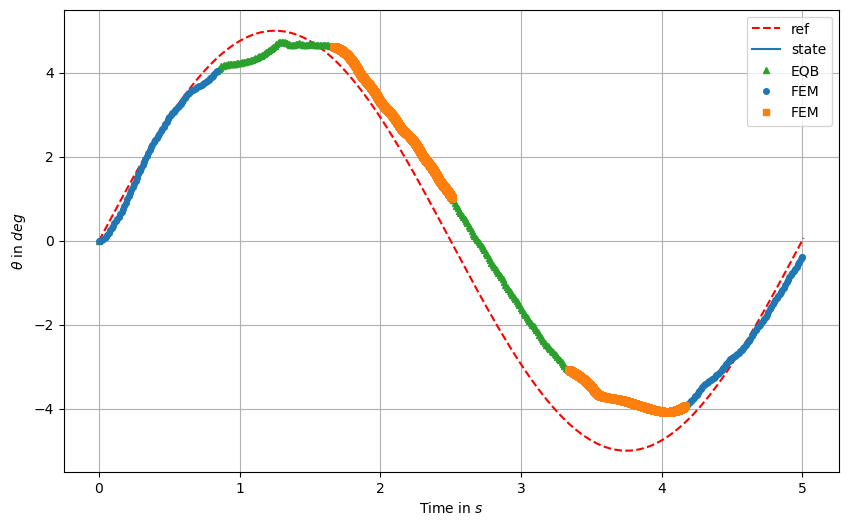

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(t_ref_vals, np.rad2deg(q_ref_vals), label='ref', color='red', linestyle='--')
plt.plot(t_state_vals, np.rad2deg(q_state_vals), label='state')
plt.plot(t_vals_eqb, np.rad2deg(q_vals_eqb), label='EQB', **eqb_style)
plt.plot(t_vals_fem, np.rad2deg(q_vals_fem), label='FEM', **fem_style)
plt.plot(t_vals_os, np.rad2deg(q_vals_os), label='FEM', **opensim_style)
plt.xlabel(r'Time in $s$')
plt.ylabel(r'$\theta$ in $deg$')
plt.legend()
plt.grid()
plt.show()